# 010 — Exploratory Data Analysis

Inventory the dataset, validate artwork-grouped splits, visualise sample pairs and pixel distributions.

In [1]:
import sys
from pathlib import Path

# Ensure the project root is on sys.path
project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.config import settings
from scripts.dataset import (
    extract_artwork_id,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.visualization import plot_sample_pairs

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset inventory

In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
print(f"Total pairs: {len(pairs)}")
print(f"\nFirst 5 pairs:")
for rgb, ir in pairs[:5]:
    print(f"  RGB: {rgb.name}  |  IR: {ir.name}")

Total pairs: 1164

First 5 pairs:
  RGB: a1_sezione_0.jpg  |  IR: a1_sezione_0.jpg
  RGB: a1_sezione_1.jpg  |  IR: a1_sezione_1.jpg
  RGB: a1_sezione_10.jpg  |  IR: a1_sezione_10.jpg
  RGB: a1_sezione_11.jpg  |  IR: a1_sezione_11.jpg
  RGB: a1_sezione_12.jpg  |  IR: a1_sezione_12.jpg


In [4]:
artwork_ids = [extract_artwork_id(p[0].stem) for p in pairs]
counts = Counter(artwork_ids)

print(f"Unique artworks: {len(counts)}\n")
print(f"{'Artwork':<20} {'Sections':>8}")
print("-" * 30)
for artwork, n in sorted(counts.items()):
    print(f"{artwork:<20} {n:>8}")
print("-" * 30)
print(f"{'Total':<20} {sum(counts.values()):>8}")

Unique artworks: 31

Artwork              Sections
------------------------------
a1                         20
a2                         20
b1                         24
c1                         20
corpo                      15
cristo                     20
mano                       24
mod                       120
natmorta1                  35
natmorta2                  35
natmorta3                  35
oblato_tot                 35
oblato_volto               42
orecchio                   24
q1                         24
q2                         20
q3                         24
santo                      30
sch01                      25
sch02                      30
sch03                      30
tbianco                    18
tblu                       84
tbruno                     47
testa                      24
tgiallo                    77
torso                      36
trosso                     60
tverde                    110
veste                      36
volto             

## 2. Train / val / test split by artwork

**Split used project-wide: artwork-and-mockups.** Real artworks are grouped and kept entirely within one fold, exactly as a plain grouped split would do, so no painting leaks across train/val/test. The mockup groups (`settings.MOCKUP_ARTWORK_IDS` — `tblu`, `tbianco`, `tbruno`, `tgiallo`, `trosso`, `tverde`) exist purely to be learned from, so a whole-group holdout would waste them; they are instead split at the individual-pair level, with only `mockup_test_ratio` (default 5%) held out for test. This is the split every training/evaluation notebook in the project uses.


In [5]:
train_pairs, val_pairs, test_pairs = mockup_aware_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    seed=settings.SEED,
)

train_artworks = sorted({extract_artwork_id(p[0].stem) for p in train_pairs})
val_artworks   = sorted({extract_artwork_id(p[0].stem) for p in val_pairs})
test_artworks  = sorted({extract_artwork_id(p[0].stem) for p in test_pairs})

print(f"Train: {len(train_pairs):>4} patches | {len(train_artworks):>2} artworks: {train_artworks}")
print(f"Val:   {len(val_pairs):>4} patches | {len(val_artworks):>2} artworks: {val_artworks}")
print(f"Test:  {len(test_pairs):>4} patches | {len(test_artworks):>2} artworks: {test_artworks}")


Train:  863 patches | 23 artworks: ['c1', 'corpo', 'cristo', 'mano', 'mod', 'natmorta2', 'natmorta3', 'oblato_tot', 'oblato_volto', 'orecchio', 'q1', 'q2', 'santo', 'sch02', 'tbianco', 'tblu', 'tbruno', 'testa', 'tgiallo', 'torso', 'trosso', 'tverde', 'volto']
Val:    166 patches | 10 artworks: ['a2', 'b1', 'sch01', 'sch03', 'tbianco', 'tblu', 'tbruno', 'tgiallo', 'trosso', 'tverde']
Test:   135 patches | 10 artworks: ['a1', 'natmorta1', 'q3', 'tbianco', 'tblu', 'tbruno', 'tgiallo', 'trosso', 'tverde', 'veste']


Integrity check for the artwork-and-mockups split: **real** artworks must still be leakage-free across folds (mockup groups are expected to appear in more than one fold by design — that's the whole point of splitting them at the pair level — so they are excluded from the leakage check). Every pair must be accounted for exactly once across train/val/test.


In [6]:
# Verify no *real* artwork appears in more than one fold — mockup groups
# are excluded on purpose, since mockup_aware_train_val_test_split spreads
# their individual pairs across folds by design.
real_train = set(train_artworks) - set(settings.MOCKUP_ARTWORK_IDS)
real_val   = set(val_artworks)   - set(settings.MOCKUP_ARTWORK_IDS)
real_test  = set(test_artworks)  - set(settings.MOCKUP_ARTWORK_IDS)

assert not (real_train & real_val),  "Leakage: train ∩ val"
assert not (real_train & real_test), "Leakage: train ∩ test"
assert not (real_val   & real_test), "Leakage: val ∩ test"
assert len(train_pairs) + len(val_pairs) + len(test_pairs) == len(pairs), "Total mismatch"
print("All split integrity checks passed.")


All split integrity checks passed.


## 3. Sample RGB / IR pair visualisation

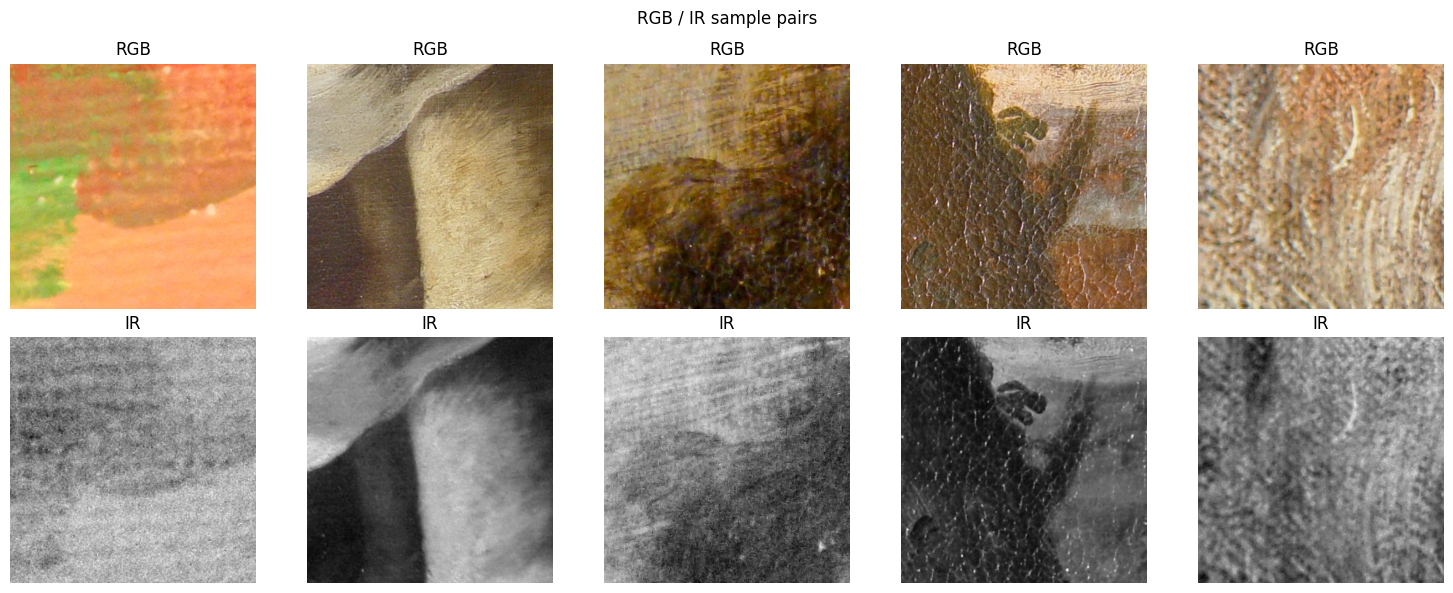

In [7]:
random.seed(settings.SEED)
sample = random.sample(pairs, min(5, len(pairs)))

rgb_imgs = [np.array(Image.open(p[0]).convert("RGB")) / 255.0 for p in sample]
ir_imgs  = [np.array(Image.open(p[1]).convert("L"))  / 255.0 for p in sample]

fig = plot_sample_pairs(rgb_imgs, ir_imgs, n=5)
plt.show()

## 4. Pixel intensity distributions

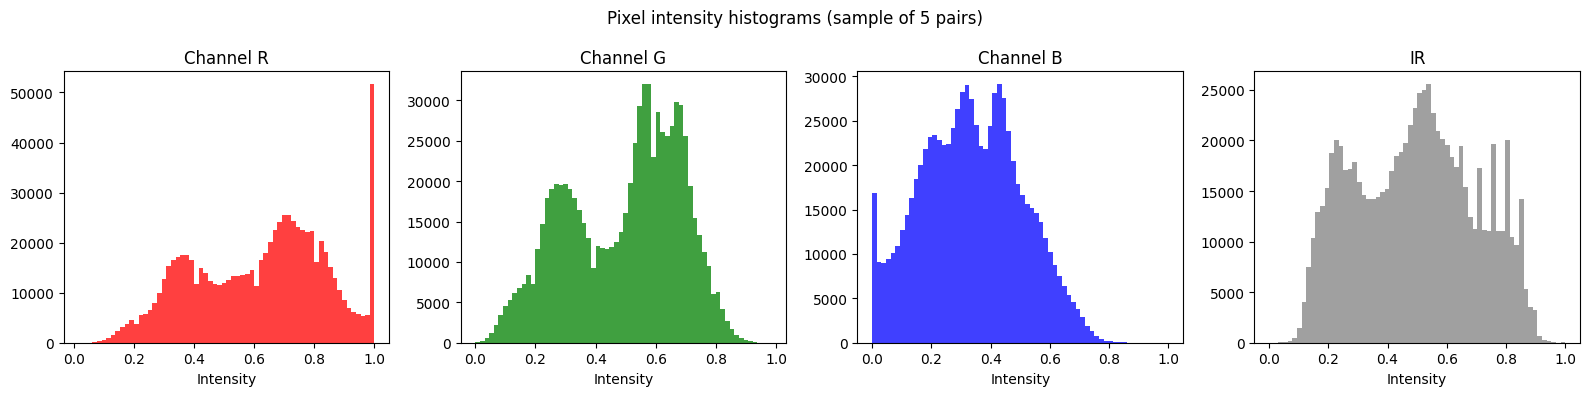

In [8]:
rgb_arr = np.stack(rgb_imgs)   # (N, H, W, 3)
ir_arr  = np.stack(ir_imgs)    # (N, H, W)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Pixel intensity histograms (sample of 5 pairs)")

for i, (ch, col) in enumerate(zip(["R", "G", "B"], ["red", "green", "blue"])):
    axes[i].hist(rgb_arr[..., i].ravel(), bins=64, color=col, alpha=0.75)
    axes[i].set_title(f"Channel {ch}")
    axes[i].set_xlabel("Intensity")

axes[3].hist(ir_arr.ravel(), bins=64, color="gray", alpha=0.75)
axes[3].set_title("IR")
axes[3].set_xlabel("Intensity")

plt.tight_layout()
plt.show()

## 5. Image dimensions check

In [9]:
# RGB/IR size agreement is now enforced for every pair by
# load_image_pairs() itself (it raises ValueError on any mismatch), so
# `pairs` above is already guaranteed consistent. This cell is purely
# descriptive: it reports the distribution of image sizes present.
sizes = {}
for rgb_path, _ in pairs:
    rgb_size = Image.open(rgb_path).size  # (W, H)
    sizes[rgb_size] = sizes.get(rgb_size, 0) + 1

print("Unique image sizes (W×H) across all pairs:")
for size, count in sorted(sizes.items()):
    print(f"  {size[0]}×{size[1]}: {count} images")
print(f"\nPATCH_MULTIPLE = {settings.PATCH_MULTIPLE}")
print(f"400 mod {settings.PATCH_MULTIPLE} = {400 % settings.PATCH_MULTIPLE} (0 = no padding needed at training time)")

Unique image sizes (W×H) across all pairs:
  400×400: 1164 images

PATCH_MULTIPLE = 16
400 mod 16 = 0 (0 = no padding needed at training time)
